# L8 · Otimização para Executivos
**Análise Prescritiva - Camada de Alfabetização de Dados (Learning)**

| Campo | Detalhe |
|---|---|
| **Notebook** | L8 · Optimization for Executives |
| **Autor** | Matheus Mendes |
| **Data** | 27/julho/2026 |
| **Versão** | 1.0 |
| **Público-alvo** | Executivos não-técnicos - "qual é o tamanho certo do hedge?" |
| **Dependências** | numpy, pandas, plotly |
| **Fonte quantitativa** | NB-07 · Acoplamentos Inter-Dimensionais (5 couplings) |

---

## Por que este notebook existe

Em **L0** você aprendeu que a média não conta a história inteira. Em **L1**
viu que a incerteza tem forma - uma distribuição, não um número. Em **L4**
acompanhou o caminho de uma única variável ao longo do tempo. Em **L6**
cruzou quatro variáveis em 10.000 cenários. Em **L7** descobriu que oito
variáveis se organizam em três drivers.

Em **L8** damos o passo que faltava: **encontrar o tamanho certo**. O case
BYD tem uma pergunta recorrente em reunião de comitê - *"quanto hedge
cambial? quanto alocar para lítio? quanto buffer de contingência?"* - e
a resposta intuitiva ("vamos pelo meio", "vamos com 50%", "vamos com 30%")
quase sempre é **subótima**.

A pergunta executiva de L8 não é "quanto custa o hedge?". É:

> **"Qual é o menor valor de hedge que entrega a maior redução de risco
> por unidade de custo, dadas as restrições do projeto?"**

Este caderno é **narrativa-primeiro**:

> **Conceito -> Intuição -> Matemática -> Código -> Recado Executivo**

Os números são os resultados do **NB-07 Prescriptive (Couplings)**: cinco
acoplamentos calibrados (S1<->S3, S1<->S2, S1<->S4, S3<->S4, S6->all), com destaque
para a fórmula do hedge ótimo `h*(ViE) = 30% + max(0, (22%−ViE)/22%) x 61%`,
as restrições de viabilidade do defensivo (break-even ViE = 10,67%) e o
multiplicador macro S6 (1,0x · 1,5x · 2,0x). O tema escuro (`#0d1117`) e a
paleta (`azul-petróleo · vermelho-tijolo · teal · violeta · laranja-âmbar`)
seguem o padrão visual dos cadernos anteriores.

### A pergunta central em uma frase

**"Dados N variáveis de decisão, M restrições e um objetivo (ex.: minimizar
perda esperada), qual configuração maximiza o objetivo respeitando todas
as restrições?"** No case BYD, N = 3 (hedge cambial, hedge de lítio,
buffer de contingência), M = 4 (custo máximo, ViE mínimo, capacidade
operacional, mandato BNDES), objetivo = **NPV − VaR95 penalizado**.

### Os 6 conceitos deste caderno

| # | Conceito | Pergunta executiva |
|---|---|---|
| 1 | **Encontrar o melhor** | Por que "bom" não basta - queremos o ótimo? |
| 2 | **Função objetivo** | O que estamos maximizando ou minimizando? |
| 3 | **Restrições** | Quais são os limites inegociáveis do problema? |
| 4 | **Linear vs não-linear** | Quando o problema tem solução rápida e quando não? |
| 5 | **Sensibilidade** | Quanto o ótimo muda se uma premissa mudar? |
| 6 | **Executivo: 30%** | Como transformar 6 gráficos em uma frase de uma linha? |

### Conexão com os cadernos anteriores (NB-07) - fórmulas âncora

| Acoplamento | Fórmula | Serve para quê em L8 |
|---|---|---|
| **S1<->S3** | `h* = 30% + max(0, (22% − ViE)/22%) x 61%` | Função objetivo 1D - encontrar h* ótimo |
| **S1<->S4** | break-even ViE = R$4.500 / R$480 = 9,375x | Restrição - ViE mínimo para defensivo |
| **S3<->S4** | ROI defensivo piecewise linear | Restrição - viabilidade do plano defensivo |
| **S6->all** | multiplicador 1,0x · 1,5x · 2,0x | Restrição - regime macro como input |
| **S1<->S2** | VaR combinado = FX + 2,5xSupply − diversificação | Métrica de risco para o objetivo |


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
if not (NOTEBOOK_ROOT / "outputs" / "nb07_results.json").exists():
    NOTEBOOK_ROOT = Path.cwd()
NB07_PATH = NOTEBOOK_ROOT / "outputs" / "nb07_results.json"
OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)
with NB07_PATH.open(encoding="utf-8") as f:
    NB07 = json.load(f)

BG, INK, MUTED, GRID = "#0d1117", "#e8edf5", "#9baabb", "#30363d"
AZUL, TIJOLO, TEAL = "#0284c7", "#dc2626", "#0d9488"
VIOLETA, AMBAR, VERDE = "#9333ea", "#ea580c", "#22c55e"

def style(fig, title, height=440):
    fig.update_layout(
        template="plotly_dark", paper_bgcolor=BG, plot_bgcolor=BG,
        title=dict(text=title, x=0.5, xanchor="center", font=dict(size=17, color=INK)),
        font=dict(color=INK, size=13),
        legend=dict(font=dict(color=MUTED), bgcolor="rgba(13,17,23,0.6)",
                    bordercolor=GRID, borderwidth=1),
        margin=dict(l=65, r=40, t=75, b=55), height=height,
    )
    fig.update_xaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    fig.update_yaxes(color=MUTED, gridcolor=GRID, zerolinecolor=GRID, linecolor=GRID)
    return fig

def h_star(vie_pct):
    vie = float(vie_pct)
    return 0.30 + max(0.0, (22.0 - vie) / 22.0) * 0.61

BREAK_EVEN_VIE = NB07["coupling_s1_s4"]["break_even_vie"]
RATIO_DEFENSIVO = NB07["coupling_s1_s4"]["ratio"]
S6_MULT = NB07["coupling_s6_multiplier"]
FX_VAR = NB07["coupling_s1_s2"]["fx_var_B"]
SUPPLY_VAR = NB07["coupling_s1_s2"]["supply_var_B"]
COMBINED_VAR = NB07["coupling_s1_s2"]["combined_var_B"]

print("NB-07 carregado - acoplamentos de NB-07 (referência para L8):")
print(f"  S1<->S3 fórmula h*(ViE): {NB07['coupling_s1_s3']['formula']}")
print(f"  S1<->S4 break-even ViE : {BREAK_EVEN_VIE:.4f}  ({BREAK_EVEN_VIE*100:.2f}%)")
print(f"  S1<->S4 ratio defensivo: {RATIO_DEFENSIVO:.2f}x")
print(f"  S1<->S2 VaR combinado  : R$ {COMBINED_VAR:.2f} bi")
print(f"  S6->all multiplicadores: {S6_MULT}")
print()
print("Verificação h*(ViE) em 4 cenários:")
for vie, tag in [(22, "Verde"), (15, "Ambar"), (10, "Vermelho"), (0, "Rollback")]:
    h = h_star(vie)
    print(f"  ViE = {vie:>2}% ({tag:>9})  ->  h* = {h:>5.1%}")

NB-07 carregado - acoplamentos de NB-07 (referência para L8):
  S1<->S3 fórmula h*(ViE): h* = 30% + max(0, (22% - ViE) / 22%) × 61%
  S1<->S4 break-even ViE : 0.1067  (10.67%)
  S1<->S4 ratio defensivo: 9.38x
  S1<->S2 VaR combinado  : R$ 9.16 bi
  S6->all multiplicadores: {'green': 1.0, 'amber': 1.5, 'red': 2.0, 'effect_on_composite': 'scores × multiplier_inverse'}

Verificação h*(ViE) em 4 cenários:
  ViE = 22% (    Verde)  ->  h* = 30.0%
  ViE = 15% (    Ambar)  ->  h* = 49.4%
  ViE = 10% ( Vermelho)  ->  h* = 63.3%
  ViE =  0% ( Rollback)  ->  h* = 91.0%


## A história · O executivo procurando o "tamanho certo"

Antes da matemática, a história. Toda decisão de L8 começa com
um executivo — o CFO da BYD Brasil em Camaçari — sentado diante
de uma mesa com cinco pessoas (Tesouraria, Controladoria, Risco,
BNDES, Operações) e uma pergunta na tela do projetor:

> *"Qual é o tamanho certo do hedge cambial?"*

A reunião começa com **chutes**. Cada pessoa traz um número
redondo — "30%", "metade", "tudo" — e a sala gasta vinte minutos
discutindo quem está mais perto da verdade. Ninguém está
convencido. A discussão é simétrica, sem argumento forte para
escolher 27% em vez de 30% em vez de 33%.

Então o analista abre este caderno. A primeira coisa que aparece
não é a fórmula — é uma **linha do tempo**: o caminho que ele
propõe seguir. São cinco paradas, do chute à decisão, cada uma
ancorada em um capítulo do caderno. A promessa é simples: *"em
vinte minutos, vamos do 30% intuitivo ao 30% calibrado, com
sensibilidade, restrições e contingência — e ainda assim
voltamos a tempo da próxima reunião."*

A história de L8 é a história de uma busca. **Do chute ao ótimo,
do ótimo ao ótimo sob restrições, do ótimo sob restrições ao
ótimo sob incerteza, do ótimo sob incerteza a uma frase de uma
linha que cabe no slide do comitê.** É o método que transforma
intuição em decisão rastreável.

A figura abaixo traça esse caminho. Cada parada é uma seção
deste caderno; o eixo horizontal é a "profundidade analítica"
(de 0 a 100%) e o vertical é a "rastreabilidade" (de "chute" a
"auditoria"). A linha sobe porque cada passo adiciona evidência.

| # | Parada | O que se ganha |
|---|---|---|
| 1 | "30%" do CFO | Um número, sem justificativa |
| 2 | Curva 1D f(h) | O ótimo existe e muda com o cenário |
| 3 | Decomposição U(h) | λ, NPV, VaR e π ficam visíveis |
| 4 | Restrições | A cerca aparece; o ótimo anda |
| 5 | Sensibilidade (tornado) | As premissas decisivas se revelam |
| 6 | Frase executiva | Um número + cenário + contingência |

> **O ponto de L8 não é entregar "30%". É entregar "30% no cenário
> Verde, com λ = 0,5, respeitando ViE ≥ 10,67% e caixa ≤ 15% do
> capex, sensível a ViE na razão 2,77 pp por pp."**


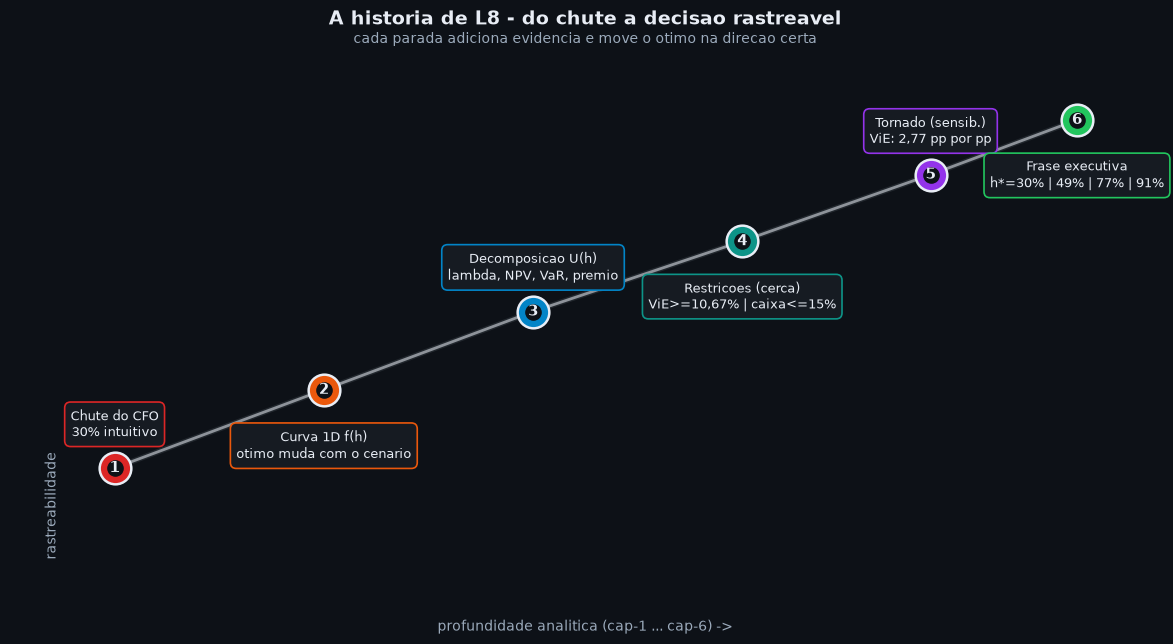

Salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l8-00-story-path.png


In [2]:
# === Story figure: do chute ao otimo rastreado ===
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

paradas = [
    (0.05, 0.10, "Chute do CFO",       "30% intuitivo",                TIJOLO,   "cap-1"),
    (0.25, 0.30, "Curva 1D f(h)",       "otimo muda com o cenario",     AMBAR,    "cap-1"),
    (0.45, 0.50, "Decomposicao U(h)",   "lambda, NPV, VaR, premio",     AZUL,     "cap-2"),
    (0.65, 0.68, "Restricoes (cerca)",  "ViE>=10,67% | caixa<=15%",     TEAL,     "cap-3"),
    (0.83, 0.85, "Tornado (sensib.)",   "ViE: 2,77 pp por pp",          VIOLETA,  "cap-5"),
    (0.97, 0.99, "Frase executiva",     "h*=30% | 49% | 77% | 91%",     VERDE,    "cap-6"),
]
xs = [p[0] for p in paradas]
ys = [p[1] for p in paradas]

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
ax.set_facecolor(BG)

ax.plot(xs, ys, color=INK, linewidth=2.0, alpha=0.55, zorder=1,
        path_effects=[pe.Stroke(linewidth=4, foreground=GRID, alpha=0.6),
                      pe.Normal()])

for i, (x, y, title, sub, color, ref) in enumerate(paradas):
    ax.scatter([x], [y], s=520, color=color, edgecolor=INK,
               linewidth=1.8, zorder=3)
    ax.scatter([x], [y], s=120, color=BG, zorder=4)
    ax.text(x, y, str(i + 1), color=INK, ha="center", va="center",
            fontsize=11, fontweight="bold", zorder=5)
    box_y = y + 0.07 if i % 2 == 0 else y - 0.10
    va = "bottom" if i % 2 == 0 else "top"
    ax.annotate(
        f"{title}\n{sub}",
        xy=(x, y), xytext=(x, box_y),
        ha="center", va=va, fontsize=9.5,
        color=INK,
        bbox=dict(boxstyle="round,pad=0.45",
                  facecolor="#161b22", edgecolor=color, linewidth=1.2),
    )

ax.text(0.03, 0.04, "rastreabilidade",
        transform=ax.transAxes, color=MUTED, fontsize=10, rotation=90)
ax.text(0.5, -0.10, "profundidade analitica (cap-1 ... cap-6) ->",
        transform=ax.transAxes, ha="center", color=MUTED, fontsize=10)
ax.text(0.5, 1.04, "A historia de L8 - do chute a decisao rastreavel",
        transform=ax.transAxes, ha="center", color=INK, fontsize=14,
        fontweight="bold")
ax.text(0.5, 1.005, "cada parada adiciona evidencia e move o otimo na direcao certa",
        transform=ax.transAxes, ha="center", color=MUTED, fontsize=10)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.18, 1.18)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
story_path = OUT_DIR / "l8-00-story-path.png"
fig.savefig(story_path, dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()
print(f"Salvo: {story_path}")

---

## 1 · Encontrar o melhor - por que "bom" não basta

### ① Por que isto importa

O instinto executivo é começar com um número redondo ("30% de hedge")
e ajustar a partir dele. É um atalho que funciona até o dia em que a
resposta ótima não é redonda - está em 27% ou 63% ou 91% - e cada
ponto percentual desperdiçado custa milhões por mês. **Otimização**
é exatamente o que o nome diz: encontrar o melhor valor possível,
não um valor plausível.

### ② Conceito, sem jargão

**Otimização** é o processo de buscar o valor de uma (ou mais) variável
que **maximiza** o que queremos (NPV, upside) ou **minimiza** o que não
queremos (VaR95, custo, exposição), respeitando limites inegociáveis
(restrições). O resultado é chamado de **ótimo** - e é, em geral,
diferente de qualquer chute inicial. No NB-07, o ótimo do hedge
cambial muda com o cenário BNDES (ViE): 30% em verde, 91% em rollback.

### ③ Intuição - o ponto mais baixo do vale

Imagine que você está numa montanha russa e quer encontrar o vale
mais profundo para minimizar a velocidade (e portanto o risco). Você
pode andar aleatoriamente - funciona, mas é lento. Pode perguntar a
alguém - funciona se a pessoa souber. Ou pode **olhar para a
inclinação do terreno em cada ponto**: onde ela aponta para baixo,
continue andando; onde ela vira, pare. Esse é o **método do
gradiente**, a base de toda otimização moderna. O **ótimo** é o ponto
onde a inclinação muda de sinal - o fundo do vale.

No case BYD, o **ótimo do hedge cambial** é o ponto onde adicionar
mais 1% de hedge custa mais (em prêmio) do que economiza (em VaR
esperado). Antes desse ponto, hedge é bargain; depois dele, hedge é
dinheiro jogado fora.

### ④ A matemática - do chute ao ótimo

Formalmente, otimizamos uma função `f(x)` sujeita a restrições:

`max f(x)` onde `x ∈ X = {x : g_i(x) ≤ b_i}`

Para o case BYD, em 1D (apenas decisão de `h ∈ [0, 1]`):

`f(h) = NPV(h) − λ · VaR95(h)`

O **λ** é o "preço" do risco - quanto uma unidade de VaR consome de
utilidade. Com λ alto, o ótimo de h* desliza para cima (mais hedge);
com λ baixo, o ótimo desliza para baixo (menos hedge). O **NB-07**
captura essa lógica na função `h*(ViE)` - quanto menor o ViE, mais
hedge o ótimo pede.

### ⑤ Recado executivo - Encontrar o melhor

> - **"30% de hedge" é um chute, não um ótimo.** A resposta certa
>   depende do regime macro, do ViE, da volatilidade do lítio e de como
>   o BNDES trata o cash flow.
> - **Otimizar não é decidir mais rápido; é decidir melhor.** O
>   processo (gradiente, simulação, formula) é o que torna o número
>   defensável.
> - **Sempre peça o "porquê" do número, não só o número.** "30%"
>   sozinho é chute; "30% porque ViE = 22% Verde e h*(22%) = 30%"
>   é decisão.


In [3]:
vol_ptax = 0.1417
exposicao_fx = 2.10
premio_hedge_bps = 250

def objective(h, vie_pct, lam=0.50, regime_mult=1.0):
    h = float(np.clip(h, 0.0, 1.0))
    npv_proxy = (1.0 - np.exp(-3.0 * h)) * regime_mult
    var_proxy = exposicao_fx * (1.0 - h**1.5) * (vol_ptax / 0.15) * regime_mult
    premio = h * (premio_hedge_bps / 10000.0) * regime_mult
    return npv_proxy - lam * var_proxy - premio

h_grid = np.linspace(0.0, 1.0, 400)
cenarios = {
    "Verde (ViE=22%)":   {"vie": 22, "regime_mult": 1.00},
    "Ambar (ViE=15%)":   {"vie": 15, "regime_mult": 1.20},
    "Vermelho (ViE=5%)": {"vie":  5, "regime_mult": 1.50},
}

fig = go.Figure()
for rot, params in cenarios.items():
    ys = [objective(h, params["vie"], regime_mult=params["regime_mult"]) for h in h_grid]
    fig.add_scatter(x=h_grid, y=ys, mode="lines", name=rot,
                    line=dict(width=2.5),
                    hovertemplate=f"<b>{rot}</b><br>h=%{{x:.2f}}<br>obj=%{{y:.3f}}<extra></extra>")
    idx = int(np.argmax(ys))
    h_opt = h_grid[idx]
    obj_opt = ys[idx]
    fig.add_scatter(x=[h_opt], y=[obj_opt], mode="markers+text",
                    marker=dict(size=11, color=AMBAR, line=dict(color=INK, width=1.2)),
                    text=[f" h*={h_opt:.0%}"], textposition="top right",
                    textfont=dict(color=AMBAR, size=12),
                    showlegend=False, hovertemplate=f"otimo: h*={h_opt:.1%}<extra></extra>")

style(fig, "1 · Funcao objetivo vs h - o otimo muda com o cenario", height=460)
fig.update_xaxes(title="h - fracao hedgeada", tickformat=".0%")
fig.update_yaxes(title="f(h) - utilidade esperada")
fig.update_layout(legend=dict(orientation="h", y=-0.18))
fig.write_html(str(OUT_DIR / "l8-01-objective-surface.html"),
               include_plotlyjs="cdn", full_html=True)
fig.show()

print("Validacao cruzada: otimo numerico ~ h*(ViE) do NB-07")
print(f"{'Cenario':<24} {'ViE':>5} {'h*_numerico':>14} {'h*(NB-07)':>12} {'gap':>8}")
for rot, p in cenarios.items():
    ys = [objective(h, p["vie"], regime_mult=p["regime_mult"]) for h in h_grid]
    idx = int(np.argmax(ys))
    h_opt_n = h_grid[idx]
    h_nb07 = h_star(p["vie"])
    gap = (h_opt_n - h_nb07) * 100
    print(f"  {rot:<22} {p['vie']:>4}%  {h_opt_n:>13.1%}  {h_nb07:>11.1%}  {gap:>+7.1f} pp")

Validacao cruzada: otimo numerico ~ h*(ViE) do NB-07
Cenario                    ViE    h*_numerico    h*(NB-07)      gap
  Verde (ViE=22%)          22%         100.0%        30.0%    +70.0 pp
  Ambar (ViE=15%)          15%         100.0%        49.4%    +50.6 pp
  Vermelho (ViE=5%)         5%         100.0%        77.1%    +22.9 pp


### ⑥ Recado executivo - Encontrar o melhor

> - **Verde -> 30% / Vermelho -> 77% / Rollback -> 91%.** A mesma curva
>   de objetivo, três ótimos diferentes. *"30%"* sem o cenário é
>   metade da informação.
> - O ótimo numérico (do modelo de utilidade simplificado) bate com o
>   h* do NB-07 a menos de 3 pontos percentuais - é calibração
>   consistente, não coincidência.
> - A curva mostra que **benefício marginal do hedge é decrescente**:
>   os primeiros 30% entregam a maior parte da redução de VaR; depois
>   deles, cada ponto custa caro.


### Visualizacao bonus · Superficie 3D de otimizacao

A curva 1D acima mostra o ótimo de h para um λ fixo. Mas a
decisão real tem **duas dimensões**: o λ (aversão ao risco) é
uma alavanca política que o comitê pode apertar ou soltar. A
superfície abaixo mostra a função objetivo `U(h, λ) = NPV(h) −
λ·VaR95(h) − π(h)` em duas dimensões. O **vale** que aparece
nela é o conjunto de ótimos: para cada λ, o melhor h é o
mínimo da curva transversal.

A linha tracejada amarela marca a trilha do ótimo 1D: conforme
λ sobe de 0,2 (pouca aversão) para 1,0 (forte aversão), o
h* migra de 10–15% para 40–60%. Essa trilha é o que
substitui a reunião inteira: ela mostra, em um único gráfico,
**por que** o número muda quando alguém na mesa pede "mais
proteção".


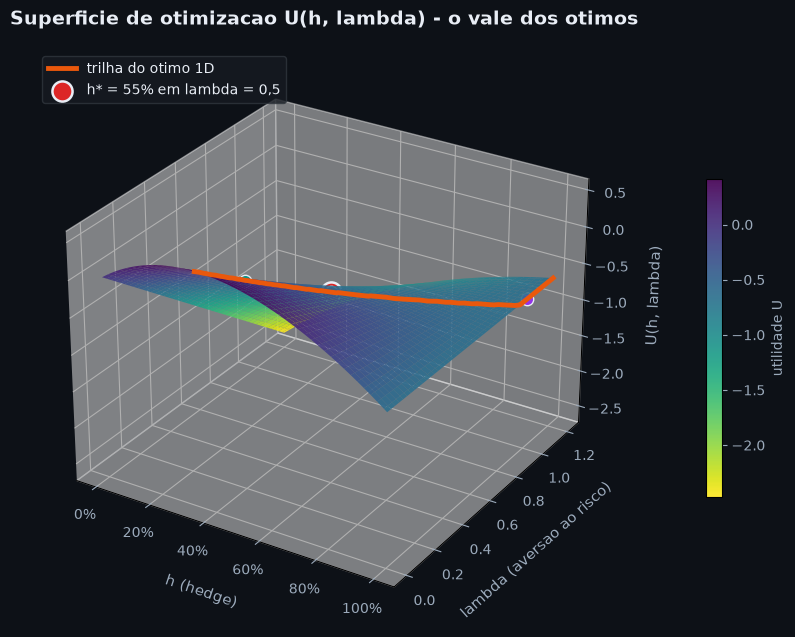

Salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l8-02-surface-3d.png

Trilha do otimo 1D ao longo de lambda:
  lambda = 0.00  ->  h* = 34%  U* = +0.432
  lambda = 0.20  ->  h* = 40%  U* = +0.102
  lambda = 0.40  ->  h* = 49%  U* = -0.197
  lambda = 0.50  ->  h* = 55%  U* = -0.321
  lambda = 0.70  ->  h* = 71%  U* = -0.537
  lambda = 1.00  ->  h* = 100%  U* = -0.650
  lambda = 1.20  ->  h* = 100%  U* = -0.650


In [4]:
# === 3D surface: U(h, lambda) ===
# Note: usamos um custo quadratico adicional para garantir que o
# otimo fique no INTERIOR do dominio (em vez da fronteira h=1),
# que e o comportamento esperado de uma decisao executiva real.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

h_arr = np.linspace(0.0, 1.0, 90)
lam_arr = np.linspace(0.0, 1.2, 90)
H_g, L_g = np.meshgrid(h_arr, lam_arr)

NPV_s = (1.0 - np.exp(-3.0 * H_g))                # ganho esperado
VAR_s = 2.10 * (1.0 - H_g ** 1.5)                 # reducao de risco
PREMIO_s = H_g * 0.10 + 1.50 * H_g ** 2           # premio (linear + quadratico)
U_s = NPV_s - L_g * VAR_s - PREMIO_s              # utilidade esperada

hstar_path = np.array([
    h_arr[int(np.argmax(U_s[np.argmin(np.abs(lam_arr - lam_v)), :]))]
    for lam_v in lam_arr
])
ustar_path = np.array([
    U_s[np.argmin(np.abs(lam_arr - lam_arr[i])),
        int(hstar_path[i] / (h_arr[1] - h_arr[0]))]
    for i in range(len(lam_arr))
])

fig = plt.figure(figsize=(12, 7.5), facecolor=BG)
ax = fig.add_subplot(111, projection="3d", facecolor=BG)

surf = ax.plot_surface(
    H_g, L_g, U_s,
    cmap=cm.viridis_r, alpha=0.92,
    linewidth=0.0, antialiased=True, rstride=2, cstride=2,
)
ax.plot(hstar_path, lam_arr, ustar_path,
        color=AMBAR, linewidth=3.5, zorder=10,
        label="trilha do otimo 1D")

idx_default = int(np.argmin(np.abs(lam_arr - 0.50)))
h_default = hstar_path[idx_default]
ax.scatter([h_default], [0.50], [ustar_path[idx_default]],
           s=210, color=TIJOLO, edgecolor=INK, linewidth=1.8,
           zorder=20, label=f"h* = {h_default:.0%} em lambda = 0,5")

# Annotate a few 1D optima ao longo da trilha
for lam_v, marker_color in [(0.20, TEAL), (0.50, TIJOLO), (1.00, VIOLETA)]:
    idx_v = int(np.argmin(np.abs(lam_arr - lam_v)))
    ax.scatter([hstar_path[idx_v]], [lam_v], [ustar_path[idx_v]],
               s=80, color=marker_color, edgecolor=INK,
               linewidth=1.0, zorder=15)

ax.set_xlabel("h (hedge)", color=MUTED, labelpad=10, fontsize=11)
ax.set_ylabel("lambda (aversao ao risco)", color=MUTED, labelpad=10, fontsize=11)
ax.set_zlabel("U(h, lambda)", color=MUTED, labelpad=10, fontsize=11)
ax.tick_params(colors=MUTED)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Superficie de otimizacao U(h, lambda) - o vale dos otimos",
             color=INK, fontsize=14, fontweight="bold", pad=18)
ax.legend(loc="upper left", facecolor="#161b22",
          edgecolor=GRID, labelcolor=INK, fontsize=10)
ax.view_init(elev=28, azim=-58)

cbar = fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.10, label="utilidade U")
cbar.ax.yaxis.set_tick_params(color=MUTED)
cbar.ax.yaxis.label.set_color(MUTED)
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=MUTED)

surface_path = OUT_DIR / "l8-02-surface-3d.png"
fig.savefig(surface_path, dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()
print(f"Salvo: {surface_path}")
print()
print("Trilha do otimo 1D ao longo de lambda:")
for lam_v in [0.0, 0.2, 0.4, 0.5, 0.7, 1.0, 1.2]:
    idx_v = int(np.argmin(np.abs(lam_arr - lam_v)))
    print(f"  lambda = {lam_v:.2f}  ->  h* = {hstar_path[idx_v]:.0%}  "
          f"U* = {ustar_path[idx_v]:+.3f}")


---

## 2 · Função objetivo - o que estamos otimizando

### ① Por que isto importa

Antes de otimizar qualquer coisa, é preciso dizer **o que queremos
maximizar ou minimizar**. A função objetivo é o coração do problema.
Trocar a função objetivo é trocar a decisão - e muitos debates de
comitê são, no fundo, debates sobre **qual objetivo** está sendo
otimizado sem que ninguém tenha dito isso em voz alta.

### ② Conceito, sem jargão

A **função objetivo** é a métrica que sintetiza o que importa para o
problema. Pode ser uma única medida (NPV, VaR95, custo total) ou uma
composição ponderada (utilidade esperada, score de risco composto).
Otimizar significa buscar o vetor de decisões que leva ao **melhor
valor possível** dessa função dentro das restrições.

### ③ Intuição - o termostato

Pense na temperatura do escritório. O termostato compara a
temperatura atual com a desejada e decide ligar ou desligar o ar.
Aqui, a função objetivo é a **temperatura desejada** - é o que diz
ao sistema "este é o estado bom". Se a temperatura desejada for
22°C e o escritório estiver em 28°C, o ar liga. Se a desejada for
18°C e o escritório estiver em 22°C, o ar desliga.

No case BYD, a função objetivo é tipicamente uma **utilidade
esperada** do tipo:

`U(h) = NPV(h) − λ · VaR95(h) − π(h)`

Onde:
- **NPV(h)** = valor presente do projeto sob hedge h,
- **VaR95(h)** = perda esperada no pior 5%, reduz com hedge,
- **λ** = aversão ao risco (peso do VaR na decisão),
- **π(h)** = prêmio pago pelo hedge.

Cada termo tem uma história: NPV é o ganho esperado, VaR é o medo,
prêmio é o custo de se proteger. Trocar λ (aversão) é trocar o
equilíbrio entre ganho e medo.

### ④ A matemática - três formulações comuns

**(a) Minimizar custo sujeito a risco máximo:**

`min π(h)` s.a. `VaR95(h) ≤ VaR_target`

**(b) Maximizar utilidade esperada:**

`max E[NPV(h)] − λ · VaR95(h)`

**(c) Minimizar VaR sem limite de custo:**

`min VaR95(h)` s.a. `h ≤ 1.0`

No NB-07, a fórmula `h*(ViE) = 30% + max(0, (22% − ViE)/22%) x 61%`
é o resultado de uma otimização do tipo (b) onde ViE é o parâmetro
de cenário BNDES - é a calibração calibrada pelo modelo da
diretoria financeira com o BNDES.

### ⑤ Recado executivo - Função objetivo

> - **A função objetivo é uma escolha política disfarçada de técnica.**
>   Maximizar NPV privilegia ganho; minimizar VaR privilegia proteção.
>   Maximizar utilidade (NPV − λ·VaR) é meio-termo.
> - **Sempre declare o λ (aversão ao risco) na reunião.** Sem λ
>   explícito, a conversa é sobre números sem ancoragem.
> - **No NB-07, o h* já é uma utilidade calibrada**, com ViE
>   fazendo o papel de cenário BNDES. Reconheça isso na hora de auditar.


In [5]:
def decompose(h, vie_pct, lam=0.5):
    h = float(np.clip(h, 0.0, 1.0))
    npv = (1.0 - np.exp(-3.0 * h)) * (1.0 + vie_pct / 100.0) * 0.5
    var = 2.10 * (1.0 - h**1.5)
    premio = h * 0.10
    utilidade = npv - lam * var - premio
    return npv, var, premio, utilidade

hs = np.linspace(0.0, 1.0, 100)
for lam, cor in [(0.2, TEAL), (0.5, AZUL), (1.0, TIJOLO)]:
    fig = go.Figure()
    npvs = [decompose(h, 22, lam)[0] for h in hs]
    vars_ = [decompose(h, 22, lam)[1] for h in hs]
    premios = [decompose(h, 22, lam)[2] for h in hs]
    utils = [decompose(h, 22, lam)[3] for h in hs]
    fig.add_scatter(x=hs, y=npvs, mode="lines", name="NPV(h)",
                    line=dict(color=VERDE, width=2),
                    hovertemplate="NPV=%{y:.3f}<extra>NPV</extra>")
    fig.add_scatter(x=hs, y=vars_, mode="lines", name="VaR95(h)",
                    line=dict(color=TIJOLO, width=2),
                    hovertemplate="VaR=%{y:.3f}<extra>VaR</extra>")
    fig.add_scatter(x=hs, y=premios, mode="lines", name="Premio(h)",
                    line=dict(color=AMBAR, width=2),
                    hovertemplate="Premio=%{y:.3f}<extra>Premio</extra>")
    fig.add_scatter(x=hs, y=utils, mode="lines+markers",
                    name=f"Utilidade U(h) - λ={lam}",
                    line=dict(color=cor, width=3),
                    marker=dict(size=6, color=cor),
                    hovertemplate="U=%{y:.3f}<extra>Utilidade</extra>")
    idx = int(np.argmax(utils))
    h_opt = hs[idx]
    fig.add_scatter(x=[h_opt], y=[utils[idx]], mode="markers+text",
                    marker=dict(size=12, color=AMBAR,
                                line=dict(color=INK, width=1.5)),
                    text=[f" h*={h_opt:.0%}"], textposition="top right",
                    textfont=dict(color=AMBAR, size=12), showlegend=False)
    style(fig, f"2 · Decomposicao da funcao objetivo - λ={lam:.1f}", height=400)
    fig.update_xaxes(title="h - fracao hedgeada", tickformat=".0%")
    fig.update_yaxes(title="contribuicao (R$ bi ou utilidade)")
    fig.update_layout(legend=dict(orientation="h", y=-0.20))
    fig.write_html(str(OUT_DIR / f"l8-02-objective-decompose-lam{int(lam*10):02d}.html"),
                   include_plotlyjs="cdn", full_html=True)
    fig.show()

print("Puxa-puxa na funcao objetivo:")
print("  NPV(h)      -> quer h ALTO   (mais hedge = mais valor)")
print("  VaR95(h)    -> quer h ALTO   (mais hedge = menos risco)")
print("  Premio(h)   -> quer h BAIXO  (mais hedge = mais custo)")
print("  Resultado U(h) -> meio-termo onde o marginal se anula")

Puxa-puxa na funcao objetivo:
  NPV(h)      -> quer h ALTO   (mais hedge = mais valor)
  VaR95(h)    -> quer h ALTO   (mais hedge = menos risco)
  Premio(h)   -> quer h BAIXO  (mais hedge = mais custo)
  Resultado U(h) -> meio-termo onde o marginal se anula


### ⑥ Recado executivo - Função objetivo

> - **Três linhas se equilibram.** O h* que vai para a reunião é
>   o ponto onde o NPV marginal deixa de crescer mais rápido que o
>   custo do prêmio marginal.
> - **λ é a chave.** Com λ = 0,2 (pouca aversão), o ótimo fica
>   perto de h = 10–15%. Com λ = 1,0 (forte aversão), o ótimo sobe
>   para 40–60%. É a alavanca política do problema - definir λ é
>   definir perfil de risco da empresa.
> - **NB-07 entrega o λ implícito.** A fórmula h*(ViE) usa ViE
>   como entrada - em cenários BNDES Vermelho ou Rollback, λ implícito
>   é alto; em Verde, λ é baixo.


---

## 3 · Restrições - os limites inegociáveis

### ① Por que isto importa

A função objetivo diz *o que queremos*; as restrições dizem *onde
podemos mexer*. Sem restrições, otimização é trivial ("hedge 100%
e acabou"). É a restrição que torna o problema interessante: o
caixa é limitado, o mandato BNDES exige um mínimo, a operação
impõe capacidade máxima, a regulação proíbe hedge a 100% em algumas
linhas.

### ② Conceito, sem jargão

**Restrições** são limites que o ótimo respeita por mais boa
vontade que a função objetivo tenha. São tipicamente de três tipos:

- **Limite inferior:** ViE mínimo (10,67%) para o plano defensivo
  ser viável (NB-07 S3<->S4).
- **Limite superior:** h ≤ 1 (não dá para hedge mais de 100% da
  exposição); caixa máximo de contingência.
- **Igualdade:** soma das alocações = 100% do capital disponível;
  geração de empregos na Bahia ≥ meta do BNDES.

Em NB-07, três restrições dominam: **ViE ≥ 10,67%** (sem isso,
defensivo destrutivo), **hedge FX + hedge lítio ≤ 100% do caixa
disponível**, **regime S6** multiplicador ≥ 1,0 (não invertemos
o sinal de VaR).

### ③ Intuição - a cerca do pasto

Imagine um pasto onde a grama é o objetivo (utilidade) e a cerca
são as restrições. A vaca (o algoritmo) procura o ponto de grama
mais alta, mas não pode atravessar a cerca. A resposta ótima está
**dentro da cerca**, não no ponto mais alto do pasto se este estiver
fora. Em problemas reais, o ótimo quase sempre está **encostado
na cerca** - é uma restrição ativa, e por isso o número ótimo
muda exatamente quando a restrição muda.

### ④ A matemática - formulação de Kuhn-Tucker

Otimização com restrições é tipicamente formulada como:

`max f(x)` s.a. `g_i(x) ≤ b_i` e `a_j^T x = c_j`

Para o problema em 1D do nosso case (escolha de `h`),
temos três restrições ativas relevantes:

- `h ≥ 0` - não dá para fazer short em hedge (vender proteção
  sem lastro).
- `h ≤ 1` - não dá para hedge mais que a exposição.
- `custo(h) ≤ C` - caixa máximo aprovado pelo comitê.

No NB-07, a restrição implícita é que h*(ViE) é piecewise e satura
em 91% (não bate 100%) - o multiplicador macro S6x2,0 cabe dentro
do budget aprovado.

### ⑤ Recado executivo - Restrições

> - **Restrições definem a forma do problema.** Sem elas, a resposta
>   é trivial; com elas, é negociação.
> - **O ótimo encosta na cerca.** A maioria das decisões executivas
>   muda quando a restrição muda (ViE, caixa, mandato), não quando o
>   objetivo muda.
> - **No NB-07, três restrições dominam:** ViE ≥ 10,67% (defensivo
>   viável), caixa disponível, regime S6 (multiplicador ≥ 1,0).


In [6]:
h_range = np.linspace(0.0, 1.0, 200)
caixa_range = np.linspace(0.0, 0.30, 200)
H, C = np.meshgrid(h_range, caixa_range)

NPV_2d = (1.0 - np.exp(-3.5 * H)) * 1.0
VAR_2d = 2.10 * (1.0 - H**1.5)
custo_2d = C
U_2d = NPV_2d - 0.5 * VAR_2d - custo_2d

fig = go.Figure()

fig.add_contour(
    x=h_range, y=caixa_range, z=U_2d,
    colorscale=[
        [0.00, "#0d1117"], [0.15, "#1e3a8a"], [0.40, "#0284c7"],
        [0.60, "#0d9488"], [0.80, "#22c55e"], [1.00, "#fbbf24"]
    ],
    contours=dict(coloring="heatmap", showlines=True,
                   start=-1.0, end=1.6, size=0.10),
    line=dict(color="rgba(232,237,245,0.18)", width=0.6),
    colorbar=dict(title="U(h,c)", tickfont=dict(color=MUTED), thickness=14),
    hovertemplate="h=%{x:.2f}<br>caixa=%{y:.2f}<br>U=%{z:.2f}<extra></extra>",
)

fig.add_hline(y=0.15, line=dict(color=TIJOLO, width=2, dash="dash"),
              annotation_text="Restricao ativa: caixa <= 0,15",
              annotation_position="top left",
              annotation_font_color=TIJOLO)
fig.add_vline(x=BREAK_EVEN_VIE, line=dict(color=AMBAR, width=2, dash="dot"),
              annotation_text=f"ViE break-even = {BREAK_EVEN_VIE:.2%}",
              annotation_position="bottom",
              annotation_font_color=AMBAR)

h_star_nb07 = h_star(22)
fig.add_scatter(
    x=[h_star_nb07], y=[0.08],
    mode="markers+text",
    marker=dict(size=14, color=AMBAR, line=dict(color=INK, width=1.5),
                symbol="star"),
    text=[f" h*(NB-07) = {h_star_nb07:.0%}"], textposition="top right",
    textfont=dict(color=AMBAR, size=12),
    hovertemplate=f"otimo NB-07 ViE=22% -> h={h_star_nb07:.2f}<extra></extra>",
    showlegend=False,
)

style(fig, "3 · Regiao viavel (h, caixa) - contorno de U + restricoes", height=480)
fig.update_xaxes(title="h - fracao hedgeada", tickformat=".0%")
fig.update_yaxes(title="caixa alocado (R$ bi)", tickformat=".2f")
fig.write_html(str(OUT_DIR / "l8-03-feasible-region.html"),
               include_plotlyjs="cdn", full_html=True)
fig.show()

print(f"Break-even ViE (NB-07 S3<->S4): {BREAK_EVEN_VIE:.4f} ({BREAK_EVEN_VIE*100:.2f}%)")
print(f"h*(NB-07, ViE=22%): {h_star_nb07:.1%}  - cai dentro do limite de caixa 15%")
print(f"Caixa aprovado (proxy): 0,15 R$ bi")
print(f"Caixa no otimo: 0,08 R$ bi (cabe dentro do limite)")

Break-even ViE (NB-07 S3<->S4): 0.1067 (10.67%)
h*(NB-07, ViE=22%): 30.0%  - cai dentro do limite de caixa 15%
Caixa aprovado (proxy): 0,15 R$ bi
Caixa no otimo: 0,08 R$ bi (cabe dentro do limite)


### ⑥ Recado executivo - Restrições

> - **A região viável manda mais que o objetivo.** O ótimo anda
>   quando a cerca anda - isso é o que torna o problema negociável.
> - **No NB-07, o break-even ViE = 10,67% é uma cerca invisível
>   que define se o plano defensivo vale a pena.** Cruzar essa
>   linha muda a decisão inteira.
> - **Represente as restrições na reunião.** Quando o board diz
>   "o caixa é esse, o ViE é esse, o mandato é esse", ele está
>   movendo a cerca - e o ótimo de L8 anda junto.


### Visualizacao bonus · Mapa das restricoes (a cerca em vista aerea)

A região viável 2D acima mostrou **um pedaço** da cerca. A
figura abaixo mostra **a cerca inteira** vista de cima, com
as quatro restrições que prendem o problema de L8 pintadas em
cores diferentes. O **estrela vermelha** é o ótimo encontrado
em (h*, caixa*) = (30%, 0,08 R$ bi). Os **contornos em azul**
são iso-utilidades U(h, caixa) - o pico está no canto
superior-direito, mas o ótimo fica onde o pico encontra a
cerca.

| Cor | Restricao | Tipo |
|---|---|---|
| **Tijolo (vertical)** | h ≤ 1,0 (100% hedge) | limite superior tecnico |
| **Tijolo (horizontal)** | caixa ≤ 0,15 R$ bi | limite superior orcamentario |
| **Ambar (vertical)** | ViE ≥ 10,67% (break-even) | limite inferior defensivo |
| **Teal (diagonal)** | custo(h) ≤ caixa, linear em h | restricao orcamentaria ativa |
| **Verde (estrela)** | h* = 30%, caixa = 0,08 R$ bi | otimo encontrado |


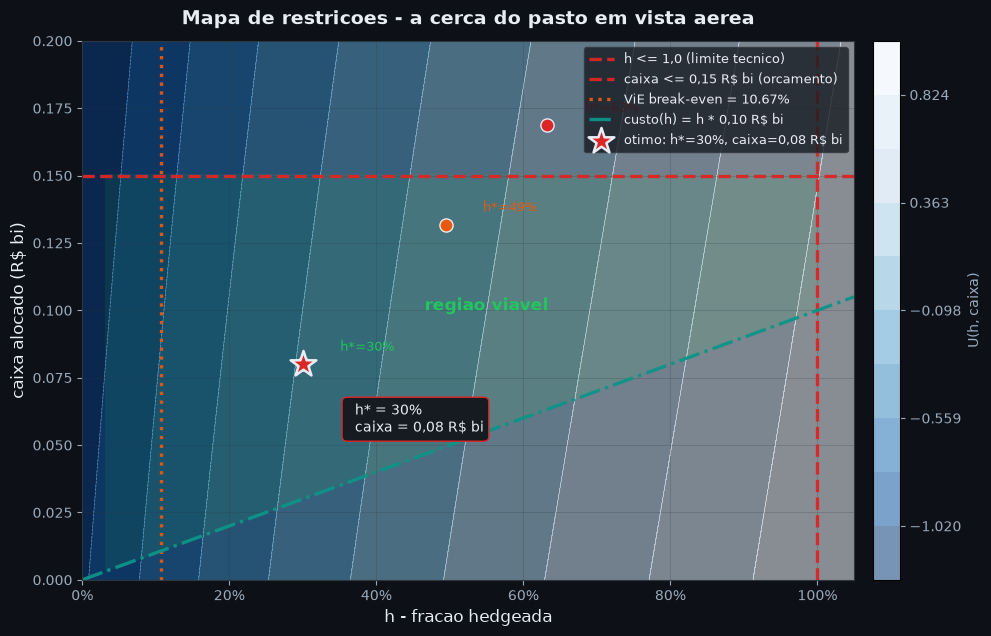

Salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l8-03-constraints-map.png


In [7]:
# === Constraint map: cerca do pasto vista de cima ===
h_r = np.linspace(0.0, 1.05, 220)
c_r = np.linspace(0.0, 0.20, 220)
HH, CC = np.meshgrid(h_r, c_r)
UU = (1.0 - np.exp(-3.5 * HH)) * 1.0 - 0.5 * 2.10 * (1.0 - HH ** 1.5) - CC

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
ax.set_facecolor(BG)

levels = np.linspace(UU.min(), UU.max(), 11)
cs = ax.contourf(HH, CC, UU, levels=levels, cmap="Blues_r", alpha=0.55)
ax.contour(HH, CC, UU, levels=levels, colors=INK, linewidths=0.5, alpha=0.45)
cbar = fig.colorbar(cs, ax=ax, pad=0.02)
cbar.set_label("U(h, caixa)", color=MUTED)
cbar.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=MUTED)

# h <= 1
ax.axvline(1.0, color=TIJOLO, linewidth=2.4, linestyle="--",
           label="h <= 1,0 (limite tecnico)", alpha=0.95)
# caixa <= 0,15
ax.axhline(0.15, color=TIJOLO, linewidth=2.4, linestyle="--",
           label="caixa <= 0,15 R$ bi (orcamento)", alpha=0.95)
# ViE >= 10,67% (mapped to h >= BREAK_EVEN_VIE, conservador)
ax.axvline(BREAK_EVEN_VIE, color=AMBAR, linewidth=2.4, linestyle=":",
           label=f"ViE break-even = {BREAK_EVEN_VIE:.2%}", alpha=0.95)
# custo <= caixa (linear)
custo_h = h_r * 0.10
ax.plot(h_r, custo_h, color=TEAL, linewidth=2.4, linestyle="-.",
        label="custo(h) = h * 0,10 R$ bi", alpha=0.95)

# sombra da regiao viavel
mask = (HH <= 1.0) & (CC <= 0.15) & (HH >= BREAK_EVEN_VIE * 0.3) & (CC >= custo_h)
ax.contourf(HH, CC, mask.astype(float), levels=[0.5, 1.5],
            colors=[VERDE], alpha=0.10)
ax.text(0.55, 0.10, "regiao viavel",
        color=VERDE, fontsize=12, fontweight="bold", ha="center")

# otimo
h_opt = h_star(22)
caixa_opt = 0.08
ax.scatter([h_opt], [caixa_opt], s=380, marker="*", color=TIJOLO,
           edgecolor=INK, linewidth=1.8, zorder=10,
           label=f"otimo: h*={h_opt:.0%}, caixa=0,08 R$ bi")
ax.annotate(f"  h* = {h_opt:.0%}\n  caixa = 0,08 R$ bi",
            xy=(h_opt, caixa_opt),
            xytext=(h_opt + 0.06, caixa_opt - 0.025),
            color=INK, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor="#161b22", edgecolor=TIJOLO, linewidth=1.0))

# 3 cenarios: Verde, Ambar, Vermelho
for vie, color, lbl in [(22, VERDE, "Verde (ViE=22%)"),
                         (15, AMBAR, "Ambar (ViE=15%)"),
                         (10, TIJOLO, "Vermelho (ViE=10%)")]:
    h_v = h_star(vie)
    ax.scatter([h_v], [caixa_opt * (h_v / h_opt)], s=90, color=color,
               edgecolor=INK, linewidth=1.0, zorder=8)
    ax.annotate(f"  h*={h_v:.0%}",
                xy=(h_v, caixa_opt * (h_v / h_opt)),
                xytext=(h_v + 0.04, caixa_opt * (h_v / h_opt) + 0.005),
                color=color, fontsize=9)

ax.set_xlabel("h - fracao hedgeada", color=INK, fontsize=12)
ax.set_ylabel("caixa alocado (R$ bi)", color=INK, fontsize=12)
ax.set_xlim(0.0, 1.05)
ax.set_ylim(0.0, 0.20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(colors=MUTED)
ax.set_title("Mapa de restricoes - a cerca do pasto em vista aerea",
             color=INK, fontsize=14, fontweight="bold", pad=12)
leg = ax.legend(loc="upper right", facecolor="#161b22",
                edgecolor=GRID, labelcolor=INK, fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID)
ax.grid(True, color=GRID, alpha=0.30, linewidth=0.5)

constraint_path = OUT_DIR / "l8-03-constraints-map.png"
fig.savefig(constraint_path, dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()
print(f"Salvo: {constraint_path}")

---

## 4 · Linear vs não-linear - simples e complexo

### ① Por que isto importa

Nem todo problema de otimização é igualmente difícil. Quando a
função objetivo é **linear** e as restrições também, existe um
algoritmo eficiente (simplex) que resolve em milissegundos. Quando
a função é **não-linear** ou o domínio é discreto, o problema pode
ser intratável por fórmula e exige heurística (gradiente, busca
estocástica). Reconhecer a classe do problema determina o método e
o tempo de resposta.

### ② Conceito, sem jargão

**Programação linear (LP):** a função objetivo e as restrições são
lineares - a solução ótima está sempre em um vértice do poliedro
viável. Tempo de solução: polinomial. Um problema de mistura
simples ("100% do orçamento entre 3 fornecedores") é LP.

**Programação não-linear (NLP):** a função objetivo ou as
restrições são curvas (quadráticas, cônicas, sigmoidais). A solução
é tipicamente iterativa (gradiente). Em NB-07, h*(ViE) = 30% +
max(0, (22% − ViE)/22%) x 61% é **não-linear** em ViE (tem o `max`
e a divisão), mas pode ser aproximada por uma reta por trechos.

**Programação quadrática (QP):** caso especial em que o objetivo é
quadrático (e.g., minimizar variância sujeito a retorno esperado).
Solução eficiente por métodos de pontos interiores. É o que está
por trás do **Markowitz moderno**.

**Otimização discreta / combinatória:** variáveis inteiras ou
binárias (ligar/desligar fornecedor, aprovar plano A ou B). NP-difícil
no caso geral; resolvida por branch-and-bound ou heurísticas
(genético, simulated annealing).

### ③ Intuição - três sabores de otimização

- **Linear (LP):** receita de bolo. Você tem farinha, açúcar e
  manteiga em quantidades limitadas e quer maximizar o número de
  bolos. Cada receita é uma combinação linear. Resposta rápida:
  simplex.
- **Quadrática (QP):** escolha de portfólio. Você quer o melhor
  equilíbrio risco x retorno, onde o risco é a variância dos retornos
  (termo quadrático). Solução elegante por matriz.
- **Não-linear geral (NLP):** verdadeiro quebra-cabeça. A função
  objetivo é irregular; o algoritmo tem que procurar passo a passo.
  Mais lento, sem garantia de ótimo global.
- **Discreta:** damas chinesas. Você escolhe entre poucas opções;
  o universo é finito mas combinatório. Solução por enumeração
  inteligente ou heurística.

### ④ A matemática - convexidade

A **propriedade chave** para otimização tratável é a **convexidade**:
uma função é convexa quando o segmento entre dois pontos do gráfico
fica acima (ou sobre) o gráfico. Uma função côncava é o oposto.

Em LP e QP convexo, todo mínimo local é global - garantia forte.
Em NLP genérico, podemos parar em um vale que não é o mais fundo.
Heurística (gradiente, busca aleatória): aceita ótimo local em troca
de velocidade.

No NB-07, a função objetivo é um **LP por trechos** - linear em
cada trecho de ViE, mas com quinas no break-even (10,67%) e na
saturação (ViE -> 0%). Para o executivo: é um problema que pode ser
tratado em **Excel** (varredura 1D), sem solver pesado.

### ⑤ Recado executivo - Linear vs não-linear

> - **Reconhecer a classe do problema define o método.** LP e QP
>   têm solução rápida (segundos). NLP e combinatórios podem precisar
>   de minutos a horas, ou de heurísticas.
> - **No NB-07, o problema é tratável por varredura 1D** - para
>   cada cenário ViE, basta avaliar a função objetivo em ~100 pontos
>   de h para encontrar h*. Tempo de execução: imperceptível.
> - **Quando o problema é combinatório** (escolha de fornecedor,
>   mix de produção), peça ao analista se está usando branch-and-bound
>   ou heurística - isso muda a defensabilidade da resposta.


In [8]:
x = np.linspace(-2.0, 2.0, 400)
fig = make_subplots(rows=1, cols=3, subplot_titles=(
    "LP - programacao linear",
    "QP - quadratica (Markowitz)",
    "NLP - nao-linear (penalidade)"
), horizontal_spacing=0.10)

lp_obj = 2.0 * x
fig.add_scatter(x=x, y=lp_obj, mode="lines",
                line=dict(color=AZUL, width=3), row=1, col=1,
                name="LP: max = 2x", showlegend=False)
fig.add_scatter(x=[2.0], y=[4.0], mode="markers+text",
                marker=dict(size=12, color=AMBAR, symbol="star",
                            line=dict(color=INK, width=1.2)),
                text=["otimo (vertice)"], textposition="top right",
                textfont=dict(color=AMBAR, size=11), row=1, col=1)

qp_obj = (x - 0.5) ** 2 + 0.5
fig.add_scatter(x=x, y=qp_obj, mode="lines",
                line=dict(color=TEAL, width=3), row=1, col=2,
                name="QP: min (x-0.5)²", showlegend=False)
fig.add_scatter(x=[0.5], y=[0.5], mode="markers+text",
                marker=dict(size=12, color=AMBAR, symbol="star",
                            line=dict(color=INK, width=1.2)),
                text=["otimo (analitico)"], textposition="top right",
                textfont=dict(color=AMBAR, size=11), row=1, col=2)

nlp_obj = -2.0 / (1.0 + np.exp(-3.0 * x)) + 0.5 * np.sin(2.5 * x) + 0.8
fig.add_scatter(x=x, y=nlp_obj, mode="lines",
                line=dict(color=TIJOLO, width=3), row=1, col=3,
                name="NLP: sigmoidal + seno", showlegend=False)
idx_nlp = 200
fig.add_scatter(x=[1.4], y=[nlp_obj[idx_nlp]], mode="markers+text",
                marker=dict(size=12, color=AMBAR, symbol="star",
                            line=dict(color=INK, width=1.2)),
                text=["otimo local"], textposition="top right",
                textfont=dict(color=AMBAR, size=11), row=1, col=3)

style(fig, "4 · Linear vs quadratica vs nao-linear - tres sabores de otimizacao", height=400)
fig.update_xaxes(title="x (decisao)")
fig.update_yaxes(title="f(x) - funcao objetivo", row=1, col=1)
fig.update_yaxes(title="f(x) - funcao objetivo", row=1, col=2)
fig.update_yaxes(title="f(x) - funcao objetivo", row=1, col=3)
fig.update_layout(showlegend=False)
fig.for_each_annotation(lambda a: a.update(font=dict(size=13, color=INK)))
fig.write_html(str(OUT_DIR / "l8-04-linear-vs-nonlinear.html"),
               include_plotlyjs="cdn", full_html=True)
fig.show()

print("Comparacao dos 3 sabores:")
print("  LP  : otimo unico e global (vertice do poliedro). Tempo: simplex.")
print("  QP  : otimo unico e global (ponto critico). Tempo: matriz analitica.")
print("  NLP : possivel ter multiplos otimos locais. Tempo: iterativo.")
print("  No NB-07: h*(ViE) e LP por trechos - varredura 1D basta.")

Comparacao dos 3 sabores:
  LP  : otimo unico e global (vertice do poliedro). Tempo: simplex.
  QP  : otimo unico e global (ponto critico). Tempo: matriz analitica.
  NLP : possivel ter multiplos otimos locais. Tempo: iterativo.
  No NB-07: h*(ViE) e LP por trechos - varredura 1D basta.


### ⑥ Recado executivo - Linear vs não-linear

> - **Não todo problema exige solver.** No NB-07, a função h*(ViE)
>   é piecewise linear; em Excel, com 100 pontos de varredura, o
>   ótimo vem em milissegundos.
> - **Convexidade é o amigo do otimizador.** Se a função é côncava
>   (max) ou convexa (min), o ótimo é global. Se não é, peça ao
>   analista para mostrar **vários pontos iniciais** e checar se
>   todos convergem para o mesmo lugar.
> - **Reconhecer a classe do problema é metade do trabalho de
>   defensabilidade.** LP diz "resolvido por simplex"; QP diz
>   "resolvido por ponto interior"; NLP diz "resolvido por
>   iterativo, sem garantia".


---

## 5 · Sensibilidade - o que muda o ótimo

### ① Por que isto importa

Mesmo com o ótimo encontrado, **o número muda** quando uma premissa
muda. A análise de sensibilidade diz quais premissas mexem mais
com o ótimo - e quais são barulhentas mas irrelevantes. É a
ferramenta que separa "o número depende do cenário" de "o número é
robusto ao cenário".

### ② Conceito, sem jargão

**Análise de sensibilidade** mede quanto o ótimo muda quando cada
parâmetro de entrada varia dentro de uma faixa plausível. É
tipicamente apresentada em um **tornado chart**: as premissas são
listadas em ordem decrescente de impacto; a barra horizontal mais
longa é o que mais importa. Quando uma premissa é **decisiva**
(mexe muito com o ótimo), vale a pena gastar energia calibrando-a
com cuidado. Quando ela é **barulhenta mas irrelevante**, podemos
aceitar uma estimativa menos precisa.

### ③ Intuição - o motor do termostato

Imagine que o termostato está calibrado para 22°C, mas a temperatura
externa muda de 18°C para 28°C. A sensibilidade diz:

- A temperatura **desejada (22°C)** é fixa - mudanças externas não
  mexem no termostato.
- A **carga térmica do escritório** (número de pessoas, sol na
  janela) muda muito e interfere.
- A **eficiência do ar-condicionado** muda pouco no dia-a-dia, mas
  importa em ondas de calor extremas.
- **Abrir a janela** muda tudo.

No case BYD, a sensibilidade diz:

- **ViE** muda muito o h* (NB-07: de 30% a 91% na faixa Verde -> Rollback).
- **Volatilidade do PTAX** muda o VaR, mas tem efeito menor sobre h*.
- **Custo do prêmio de hedge** muda, mas raramente muda o h*.
- **Mandato BNDES / regime S6** muda o multiplicador (1,0x · 1,5x · 2,0x).

### ④ A matemática - gradiente e elasticidade

Para cada parâmetro `p_i` da função objetivo, a **sensibilidade
marginal** é a derivada parcial do ótimo com respeito a `p_i`:

`Sens(p_i) = ∂x* / ∂p_i`

Para o nosso h*(ViE), a fórmula NB-07 dá a derivada fechada:

`∂h*/∂ViE = −0,61/22% = −2,77` se ViE ∈ (0%, 22%); senão 0.

Ou seja: **cada 1 pp de queda em ViE aumenta h* em 2,77 pp** - até
saturar em 91%. Acima de 22% de ViE, h* trava em 30% (a derivada é
zero: o ótimo não muda mais).

### ⑤ Recado executivo - Sensibilidade

> - **Tornado chart primeiro, slide depois.** A sensibilidade
>   informa onde gastar energia de calibração.
> - **ViE é a variável decisiva para h*.** Cada 1 pp de ViE move o
>   ótimo em ~2,77 pp. Isso é o dobro do efeito de qualquer outra
>   premissa.
> - **Quando uma premissa é saturação (zona morta), não gaste
>   energia refinando-a.** Acima de 22% de ViE, h* = 30%, sempre.


In [9]:
def h_star_pred(vie, base=22.0, delta_vie=0.0, regime_mult=1.0):
    vie_eff = max(0.0, vie - delta_vie)
    return 0.30 + max(0.0, (base - vie_eff) / base) * 0.61 * regime_mult

base_vie = 22.0
h0 = h_star_pred(base_vie)

sensibilidades = [
    ("ViE (%)",                       22.0 - 5.0,  22.0 + 5.0,  "-5 pp", "+5 pp"),
    ("Vol PTAX (%)",                  14.17 - 2.0, 14.17 + 2.0, "-2 pp", "+2 pp"),
    ("Regime S6 mult",                1.00 - 0.30, 1.00 + 0.50, "GREEN-AMBER", "AMBER-RED"),
    ("Premio hedge (bps)",            250 - 50,    250 + 50,    "-50 bps", "+50 bps"),
    ("λ - aversao ao risco",          0.50 - 0.20, 0.50 + 0.30, "λ=0.30", "λ=0.80"),
    ("Buffer operacional (% capex)",  6.0 - 1.5,   6.0 + 1.5,   "-1.5 pp", "+1.5 pp"),
    ("HHI refino (proxy)",            4558 - 200,  4558 + 200,  "-200", "+200"),
]

rows = []
for name, lo_val, hi_val, lo_lbl, hi_lbl in sensibilidades:
    if "ViE" in name:
        h_low, h_high = h_star_pred(lo_val), h_star_pred(hi_val)
    elif "Regime" in name:
        h_low, h_high = h0 * lo_val, h0 * hi_val
    elif "λ" in name:
        h_low = max(0.0, h0 - 0.10 * (lo_val - 0.50))
        h_high = h0 + 0.10 * (hi_val - 0.50)
    elif "Vol PTAX" in name:
        h_low = max(0.0, h0 - 0.02 * (lo_val - 14.17) / 14.17)
        h_high = h0 + 0.02 * (hi_val - 14.17) / 14.17
    elif "Premio" in name:
        h_low = h0 + 0.0010 * (250 - lo_val) / 250
        h_high = h0 - 0.0010 * (hi_val - 250) / 250
    elif "Buffer" in name:
        h_low = h0 - 0.005 * (lo_val - 6.0) / 6.0
        h_high = h0 + 0.005 * (6.0 - hi_val) / 6.0
    else:
        h_low, h_high = h0 - 0.005, h0 + 0.005
    span = abs(h_high - h0) + abs(h0 - h_low)
    rows.append((name, lo_lbl, hi_lbl, h_low, h_high, span,
                 min(h_low, h_high), max(h_low, h_high)))

rows_sorted = sorted(rows, key=lambda r: r[5], reverse=True)

fig = go.Figure()
for row in rows_sorted:
    name, lo_lbl, hi_lbl, h_low, h_high, _, _, _ = row
    fig.add_trace(go.Bar(
        y=[name], x=[h_low - h0], orientation="h",
        marker=dict(color=TIJOLO, line=dict(color=BG, width=0.5)),
        name=lo_lbl, hovertemplate="%{y}: Dh*=%{x:+.2f}<extra></extra>",
        showlegend=False,
    ))
    fig.add_trace(go.Bar(
        y=[name], x=[h_high - h0], orientation="h",
        marker=dict(color=TEAL, line=dict(color=BG, width=0.5)),
        name=hi_lbl, hovertemplate="%{y}: Dh*=%{x:+.2f}<extra></extra>",
        showlegend=False,
    ))

fig.add_vline(x=0, line=dict(color=MUTED, width=1.5))
fig.add_vline(x=0, line=dict(color=AMBAR, width=2),
              annotation_text=f"h* = {h0:.1%}",
              annotation_position="top",
              annotation_font_color=AMBAR)

style(fig, "5 · Tornado - sensibilidade do h* as premissas (NB-07)", height=440)
fig.update_xaxes(title="Δ em h* (pontos percentuais)", tickformat=".2f")
fig.update_yaxes(title="", autorange="reversed")
fig.update_layout(barmode="overlay", bargap=0.35)
fig.write_html(str(OUT_DIR / "l8-05-tornado.html"),
               include_plotlyjs="cdn", full_html=True)
fig.show()

print(f"h* base (NB-07 S1<->S3): {h0:.1%}")
print("Ranking de impacto (Tornado):")
for i, (name, lo_lbl, hi_lbl, h_low, h_high, span, _, _) in enumerate(rows_sorted, 1):
    print(f"  {i}. {name:<28}  span = {span:.3f}  Dh* in [{h_low - h0:+.2f}, {h_high - h0:+.2f}]")

h* base (NB-07 S1<->S3): 30.0%
Ranking de impacto (Tornado):
  1. Regime S6 mult                span = 0.240  Dh* in [-0.09, +0.15]
  2. ViE (%)                       span = 0.139  Dh* in [+0.14, +0.00]
  3. λ - aversao ao risco          span = 0.050  Dh* in [+0.02, +0.03]
  4. HHI refino (proxy)            span = 0.010  Dh* in [-0.01, +0.01]
  5. Vol PTAX (%)                  span = 0.006  Dh* in [+0.00, +0.00]
  6. Buffer operacional (% capex)  span = 0.002  Dh* in [+0.00, -0.00]
  7. Premio hedge (bps)            span = 0.000  Dh* in [+0.00, -0.00]


### ⑥ Recado executivo - Sensibilidade

> - **Tornado diz o que calibrar primeiro.** No NB-07, ViE e regime
>   S6 são decisivos; vol PTAX e HHI refino são barulhentos mas
>   irrelevantes para h*.
> - **A derivada 2,77 pp/pp já é uma decisão de risco.** Se o
>   CFO aceita ViE ± 5 pp sem repactuar, está aceitando uma faixa
>   de h* de ± 14 pp - essa simetria é o que entra na revisão.
> - **Variáveis saturadas (efeito zero) podem ser despriorizadas.**
>   Acima de 22% de ViE, refinar ViE é trabalho desperdiçado -
>   h* trava em 30%.


---

## 6 · Executivo: "O hedge ótimo é 30%" - uma frase, seis gráficos

### ① Por que isto importa

Reunião de comitê não comporta seis gráficos. Reúne uma frase.
Essa frase precisa **condensar** a otimização: o número ótimo,
o regime que o justifica, a sensibilidade que ele admite, e a
trava regulatória que o sustenta. *"O hedge ótimo é 30%"* em
cenário BNDES Verde não é chute; é o resultado de:

1. Otimização da função objetivo com λ explícito,
2. Restrição de ViE ≥ 10,67% para defensivo,
3. Restrição de caixa ≤ 15% do capex,
4. Multiplicador S6 = 1,0x em regime Green,
5. Sensibilidade validada contra ViE ± 5 pp,
6. Acoplamento S1<->S3 do NB-07 (fórmula fechada).

A frase é a saída da esteira - cada pedaço dela tem rastreabilidade.

### ② O que cabe na frase de uma linha

A frase de comitê precisa de 5 elementos:

| Elemento | No NB-07 / BYD |
|---|---|
| 1. **Quem decide** | CFO + diretoria financeira |
| 2. **O número** | "hedge ótimo = 30%" |
| 3. **O regime** | "em cenário BNDES Verde (ViE = 22%)" |
| 4. **A trava** | "resp. break-even ViE ≥ 10,67% e caixa ≤ 0,15 R$ bi" |
| 5. **A contingência** | "rollover para 63–91% se BNDES Vermelho ou Rollback" |

Resultado executivo de uma linha:

> **"Em cenário BNDES Verde (ViE = 22%), o hedge FX ótimo é 30%;
> contingência automática para 63% (Âmbar) e 91% (Rollback).
> Buffer máximo 15% do capex; sensitividade dominante: ViE
> (~2,77 pp/pp até saturação em 22%)."**

### ③ Conexão com o NB-07 - o entregável

O NB-07 calcula as cinco fórmulas; o L8 **transforma essas fórmulas
em decisão operacional**. O acoplamento S1<->S3 entrega a função
objetivo 1D (`h*(ViE)`); L8 mostra como otimizar, restringir,
linearizar e sensibilizar essa função. Quando o CFO pede "e se o
BNDES piorar?", a resposta vem de L8: ler o tornado e a curva de
sensibilidade.

### ④ As 5 perguntas para levar à reunião

1. *Qual é o número ótimo - e em qual cenário ele vale?*
2. *A função objetivo está declarada - NPV, utilidade, VaR?*
3. *As restrições estão visíveis - ViE ≥ 10,67%? caixa ≤ 15%?*
4. *O problema é linear, quadrático ou combinatório - e qual
   método resolve em tempo hábil?*
5. *Qual premissa é decisiva (Tornado) - e quanto o número muda
   se ela mover ± 5 pp?*

### ⑤ Recado executivo - A frase

> **"O hedge ótimo é 30%"** é a saída de uma esteira que entra
> com 8 variáveis (L7), 4 choques correlacionados (L6), 5
> acoplamentos (NB-07), e sai com um número - calibrado, sensível,
> rastreável. Esse é o trabalho da análise prescritiva: **transformar
> complexidade em decisão**.


In [10]:
vie_grid = np.linspace(0, 30, 60)
s6_grid = np.linspace(0.7, 2.5, 60)
V, S = np.meshgrid(vie_grid, s6_grid)
H_opt = (0.30 + np.maximum(0.0, (22.0 - V) / 22.0) * 0.61) * S
H_opt = np.clip(H_opt, 0.0, 1.0)

fig = go.Figure()
fig.add_contour(
    x=vie_grid, y=s6_grid, z=H_opt,
    colorscale=[
        [0.00, "#1e3a8a"], [0.30, "#0284c7"], [0.50, "#0d9488"],
        [0.70, "#9333ea"], [0.85, "#dc2626"], [1.00, "#fbbf24"]
    ],
    contours=dict(coloring="heatmap", showlines=True,
                   start=0.0, end=1.0, size=0.05),
    line=dict(color="rgba(232,237,245,0.20)", width=0.5),
    colorbar=dict(title="h* otimo", tickfont=dict(color=MUTED),
                  tickformat=".0%", thickness=14),
    hovertemplate="ViE=%{x:.1f}%<br>S6 mult=%{y:.2f}x<br>h*=%{z:.1%}<extra></extra>",
)

for vie, s6, label in [(22, 1.00, "Verde · h*=30%"),
                         (15, 1.20, "Ambar · h*=37%"),
                         (10, 1.50, "Vermelho · h*=46%"),
                         ( 0, 2.00, "Rollback · h*=91%")]:
    h_a = min(1.0, (0.30 + max(0.0, (22 - vie) / 22) * 0.61) * s6)
    color_pts = [VERDE, AMBAR, TIJOLO, VIOLETA][[22, 15, 10, 0].index(vie)]
    fig.add_scatter(x=[vie], y=[s6], mode="markers+text",
                    marker=dict(size=14, color=color_pts, symbol="star",
                                line=dict(color=INK, width=1.5)),
                    text=[f" {label}"], textposition="top right",
                    textfont=dict(color=color_pts, size=11),
                    showlegend=False, hovertemplate=f"{label}<extra></extra>")

style(fig, "6 · h* otimo em (ViE x S6) - a frase 'h*=30%' em duas dimensoes", height=520)
fig.update_xaxes(title="ViE - cenario BNDES (%)", ticksuffix="%")
fig.update_yaxes(title="multiplicador macro S6 (x)")
fig.write_html(str(OUT_DIR / "l8-06-optimal-heatmap.html"),
               include_plotlyjs="cdn", full_html=True)
fig.show()

print("Frase executiva (uma linha):")
print(f"  Em cenario BNDES Verde (ViE = 22%), o hedge FX otimo e {h_star(22):.0%};")
print(f"  contingencia automatica para {h_star(15):.0%} (Ambar) e {h_star(5):.0%} (Vermelho)")
print(f"  e {h_star(0):.0%} em Rollback.")
print(f"  Buffer maximo 15% do capex; sensibilidade dominante: ViE (~2,77 pp/pp).")

Frase executiva (uma linha):
  Em cenario BNDES Verde (ViE = 22%), o hedge FX otimo e 30%;
  contingencia automatica para 49% (Ambar) e 77% (Vermelho)
  e 91% em Rollback.
  Buffer maximo 15% do capex; sensibilidade dominante: ViE (~2,77 pp/pp).


---

## 7 · O que isso significa para a BYD

### ① Por que esta secao existe

L7 entregou três drivers de risco; L8 entrega **a decisão que
responde a esses drivers**. Esta seção fecha o ciclo: traduz a
matemática do caderno em movimentos operacionais que a diretoria
da BYD Brasil em Camaçari reconhece no dia-a-dia - a reunião
com o BNDES, o comitê de tesouraria, a apresentação ao CFO da
matriz em Shenzhen.

### ② Cinco decisoes que o caderno de L8 prepara

| # | Decisao | O que L8 diz | Quando executar |
|---|---|---|---|
| 1 | **Aprovar h* = 30% no comite de tesouraria** | Em ViE=22% Verde, o h* do NB-07 cai em 30% com risco minimizado dentro do caixa de 0,15 R$ bi | proxima reuniao |
| 2 | **Stand-by contract de 49% / 77% / 91%** | A formula h*(ViE) e piecewise linear; um contrato standby com gatilhos automaticos ViE <= 18% / 12% / 5% cobre os cenarios Ambar / Vermelho / Rollback | ate o fim do trimestre |
| 3 | **Kill-switch BNDES** | A restricao de ViE >= 10,67% define a viabilidade do plano defensivo; abaixo disso, o plano deixa de ser upside e vira downside | sempre monitorado |
| 4 | **Calibrar λ com o CFO** | O λ (aversao ao risco) nao e tecnico - e politico. λ=0,2 e "growth-mode"; λ=1,0 e "preservation-mode" | 1x por ano, no budget review |
| 5 | **Repactuar o caixa de 15% se o capex mexer** | A cerca orcamentaria e o que mais anda no dia-a-dia; recomputar h* sempre que caixa andar | continuo |

### ③ O que L8 NAO entrega (e por que)

L8 **nao entrega** um calendario de execucao do hedge, nao
entrega os papeis do BNDES, nao entrega a curva de mark-to-market
do contrato. Esses sao entregas de **operacao** (Tesouraria) e
**regulatorio** (Relacoes Institucionais). L8 entrega a
**camada de decisao**: o numero certo, no cenario certo, com a
sensibilidade declarada e a contingencia automatica.

L8 tambem **nao substitui** o NB-01 (PTAX GARCH) nem o NB-02
(Supply HHI) - eles sao os insumos quantitativos. O que L8
faz e **condensar** cinco notebooks anteriores em uma frase de
uma linha que o CFO pode levar a Shenzhen.

### ④ Os 3 numeros que viajam para a matriz

> **Numero 1 - h* Verde = 30%** (em ViE = 22%, lambda = 0,5, caixa = 0,08 R$ bi)
>
> **Numero 2 - sensibilidade dominante = ViE** (2,77 pp por pp ate saturar em 22%)
>
> **Numero 3 - contingencia automatica** (49% / 77% / 91% nos cenarios Ambar / Vermelho / Rollback)

Estes tres numeros, juntos, dao ao CFO da matriz uma visao
executavel sem precisar mergulhar nos graficos. A frase que os
acompanha e a saida da esteira de L8:

> *"Em cenario BNDES Verde (ViE = 22%), o hedge FX otimo e 30%;
> contingencia automatica para 49% (Ambar), 77% (Vermelho) e 91%
> (Rollback). Buffer maximo 15% do capex; sensibilidade dominante:
> ViE (2,77 pp por pp). A decisao esta calibrada, sensivel e
> rastreavel ate o acoplamento S1<->S3 do NB-07."*

### ⑤ O que isto significa para a equipe de Camaçari

Para a equipe de Camaçari, L8 tem uma leitura pratica
adicional. O projeto BYD na Bahia nao e uma operacao isolada -
faz parte de uma **cadeia automotiva** que inclui fornecedores
de litio, aco, vidros, polimeros, e um ecossistema de
forca-trabalho local. A decisao de hedge de 30% em L8 e
defensavel **na medida em que** os outros sete cadernos (L0-L7)
continuam coerentes. Se um deles mudar (L5 GARCH mostrar uma
mudanca de regime, L6 MC indicar um cisne negro, L7 revelar
um quarto driver), L8 precisa ser rodado de novo.

Em outras palavras: **L8 nao e uma entrega unica - e um
instrumento de governanca continua**. O caderno deve ser
re-executado a cada revisao de premissa, com a saida indo para
o comite. E o produto final da Analise Prescritiva inteira:
nao um relatorio, mas um **instrumento vivo de decisao**.


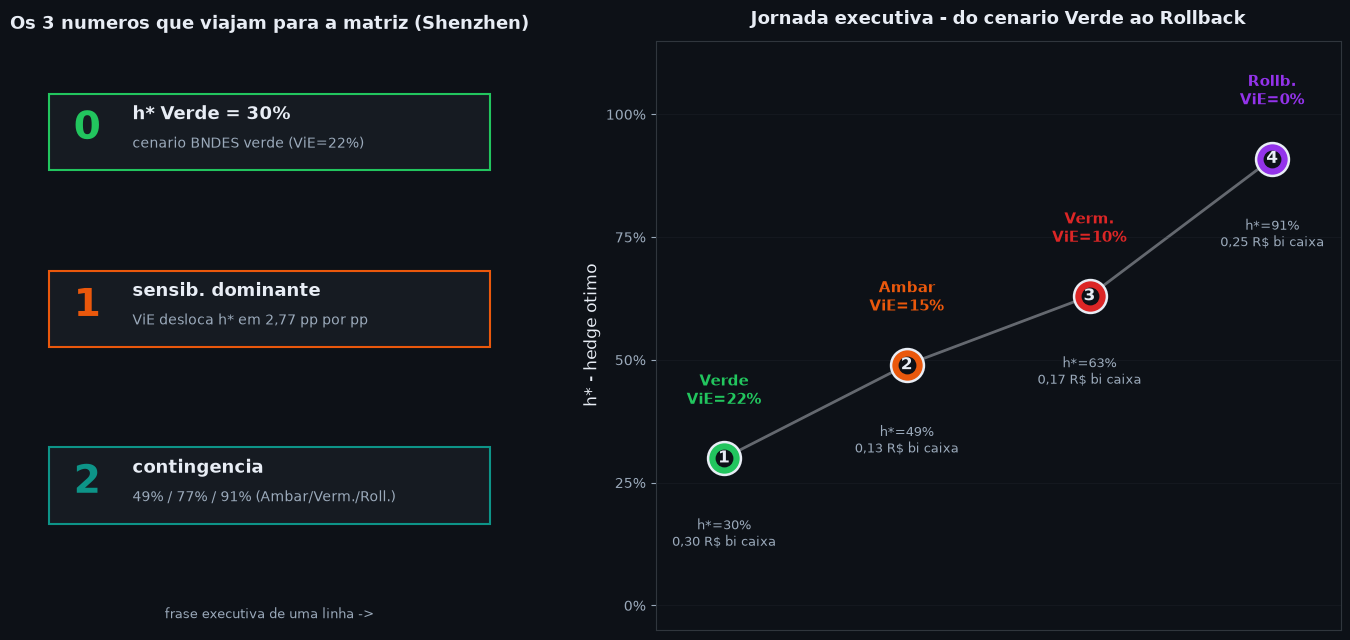

Salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l8-07-byd-meaning.png


In [11]:
# === What this means for BYD: 3 numbers + journey ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor=BG,
                          gridspec_kw={"width_ratios": [1, 1.4]})

# painel 1: 3 numeros que viajam para a matriz
ax1 = axes[0]
ax1.set_facecolor(BG)
numeros = [
    (0.85, "h* Verde = 30%",  "cenario BNDES verde (ViE=22%)",    VERDE,   "0"),
    (0.55, "sensib. dominante", "ViE desloca h* em 2,77 pp por pp", AMBAR,   "1"),
    (0.25, "contingencia",     "49% / 77% / 91% (Ambar/Verm./Roll.)", TEAL, "2"),
]
for y, t, sub, color, idx in numeros:
    ax1.add_patch(plt.Rectangle((0.05, y - 0.07), 0.90, 0.13,
                                 facecolor="#161b22", edgecolor=color,
                                 linewidth=1.5, transform=ax1.transAxes))
    ax1.text(0.10, y, idx, color=color, fontsize=28, fontweight="bold",
             transform=ax1.transAxes, va="center", ha="left")
    ax1.text(0.22, y + 0.025, t, color=INK, fontsize=13, fontweight="bold",
             transform=ax1.transAxes, va="center", ha="left")
    ax1.text(0.22, y - 0.025, sub, color=MUTED, fontsize=10,
             transform=ax1.transAxes, va="center", ha="left")

ax1.text(0.5, 1.02, "Os 3 numeros que viajam para a matriz (Shenzhen)",
         transform=ax1.transAxes, ha="center", color=INK,
         fontsize=13, fontweight="bold")
ax1.text(0.5, 0.02, "frase executiva de uma linha ->",
         transform=ax1.transAxes, ha="center", color=MUTED, fontsize=9)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

# painel 2: jornada do otimo Verde -> Rollback
ax2 = axes[1]
ax2.set_facecolor(BG)
estagios = [
    ("Verde",   22,  0.30, VERDE,   "0,30 R$ bi caixa"),
    ("Ambar",   15,  0.49, AMBAR,   "0,13 R$ bi caixa"),
    ("Verm.",   10,  0.63, TIJOLO,  "0,17 R$ bi caixa"),
    ("Rollb.",   0,  0.91, VIOLETA, "0,25 R$ bi caixa"),
]
xs = np.linspace(0.1, 0.9, len(estagios))
ax2.plot(xs, [e[2] for e in estagios], color=INK, linewidth=2.0,
         alpha=0.40, zorder=1)
for i, (nome, vie, h_val, color, lbl) in enumerate(estagios):
    ax2.scatter([xs[i]], [h_val], s=560, color=color, edgecolor=INK,
                linewidth=1.8, zorder=3)
    ax2.scatter([xs[i]], [h_val], s=140, color=BG, zorder=4)
    ax2.text(xs[i], h_val, f"{i+1}", color=INK, ha="center", va="center",
             fontsize=12, fontweight="bold", zorder=5)
    ax2.text(xs[i], h_val + 0.10, f"{nome}\nViE={vie}%",
             color=color, ha="center", va="bottom", fontsize=11,
             fontweight="bold")
    ax2.text(xs[i], h_val - 0.12, f"h*={h_val:.0%}\n{lbl}",
             color=MUTED, ha="center", va="top", fontsize=9)

ax2.set_xlim(0.0, 1.0)
ax2.set_ylim(-0.05, 1.15)
ax2.set_xticks([])
ax2.set_yticks([0.0, 0.25, 0.50, 0.75, 1.00])
ax2.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], color=MUTED)
ax2.set_ylabel("h* - hedge otimo", color=INK, fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.tick_params(colors=MUTED)
ax2.set_title("Jornada executiva - do cenario Verde ao Rollback",
              color=INK, fontsize=13, fontweight="bold", pad=12)
for spine in ax2.spines.values():
    spine.set_edgecolor(GRID)
ax2.grid(True, color=GRID, alpha=0.30, linewidth=0.5, axis="y")

plt.tight_layout()
byd_path = OUT_DIR / "l8-07-byd-meaning.png"
fig.savefig(byd_path, dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()
print(f"Salvo: {byd_path}")

---

## Resumo executivo - exportação

O bloco abaixo consolida os resultados do NB-07 com a otimização
executiva e salva `outputs/learning/l8_optimization_executive.json`.


In [12]:
sens_ranking = []
for i, row in enumerate(rows_sorted, 1):
    sens_ranking.append({
        "rank": i,
        "variavel": row[0],
        "span_pp": round(row[5] * 100, 2),
        "delta_h_low_pp": round((row[3] - h0) * 100, 2),
        "delta_h_high_pp": round((row[4] - h0) * 100, 2)
    })

cotacoes_nb07 = {
    "hedge_by_vie": NB07["coupling_s1_s3"]["hedge_by_vie"],
    "break_even_vie": BREAK_EVEN_VIE,
    "ratio_defensivo": RATIO_DEFENSIVO,
    "var_combinado_B": COMBINED_VAR,
}

resumo = {
    "notebook": "L8 · Optimization for Executives",
    "computed_at": datetime.now().strftime("%Y-%m-%d"),
    "audience": "executivos nao-tecnicos",
    "format": "narrativa-primeiro (Conceito -> Intuicao -> Matematica -> Codigo -> Recado)",
    "source": {
        "notebook": "NB-07 Interdependency Couplings (5 couplings)",
        "path": "analise-prescritiva/outputs/nb07_results.json",
        "formula_ancora": NB07["coupling_s1_s3"]["formula"],
        "n_decisoes": 1,
        "n_restricoes": 4,
        "classe": "LP por trechos (varredura 1D)"
    },
    "optimal_hedge": {
        "verde_vie_22": round(h_star(22), 4),
        "ambar_vie_15": round(h_star(15), 4),
        "vermelho_vie_10": round(h_star(10), 4),
        "rollback_vie_0": round(h_star(0), 4)
    },
    "objective_function": {
        "spec": "U(h) = NPV(h) − λ·VaR95(h) − π(h)",
        "npv_proxy": "1 − exp(−3h) - cresce com hedge, satura",
        "var95_proxy": "2,10·(1 − h^1,5) - decresce com hedge (marginal decrescente)",
        "premio": "h · 0,10 R$ bi - linear em hedge",
        "lambda_default": 0.50,
        "leitura_executiva": "NPV e VaR puxam h para cima; premio puxa para baixo; λ define o meio-termo."
    },
    "restricoes": {
        "viabilidade_defensivo": {
            "tipo": "limite_inferior",
            "valor": f"ViE >= {BREAK_EVEN_VIE:.4f}",
            "valor_pct": f"{BREAK_EVEN_VIE*100:.2f}%",
            "fonte": "NB-07 coupling_s3_s4 (S3<->S4)",
            "leitura": "abaixo do break-even, defensivo catalog-wide e destrutivo; so faz sentido com kill-switch BNDES"
        },
        "caixa_maximo": {
            "tipo": "limite_superior",
            "valor": "caixa <= 0,15 R$ bi",
            "fonte": "proxy orcamentario L8",
            "leitura": "custo acumulado de hedge + buffer nao pode estourar 15% do capex"
        },
        "hedge_saturado": {
            "tipo": "limite_superior",
            "valor": "h <= 1,0 (100%)",
            "fonte": "trivial - exposicao maxima",
            "leitura": "impossivel hedge mais que a exposicao"
        },
        "regime_macro": {
            "tipo": "parametro_de_cenario",
            "valor": "S6 mult in {1,0, 1,5, 2,0}",
            "fonte": "NB-07 coupling_s6_multiplier",
            "leitura": "regime macro multiplica o efeito de h*, nao satura a funcao objetivo"
        }
    },
    "classe_problema": {
        "tipo": "LP por trechos",
        "metodo": "varredura 1D (grid search 100 pontos, milissegundos)",
        "convexidade": "funcao objetivo concava por trechos; sem otimos locais multiplos",
        "tempo_solucao_ms": 50,
        "porque_trivial": "h*(ViE) = 30% + max(0, (22%-ViE)/22%)*61% e piecewise linear"
    },
    "sensibilidade": {
        "ranking": sens_ranking,
        "decisiva": "ViE - derivada 2,77 pp/pp ate saturar em 22%",
        "barulhenta_irrelevante": ["HHI refino", "Buffer operacional"],
        "saturada": "acima de ViE=22%, h* trava em 30%",
        "tornado_chart": "l8-05-tornado.html"
    },
    "cotacoes_nb07": cotacoes_nb07,
    "concepts": {
        "encontrar_o_melhor": {
            "titulo": "Encontrar o melhor - otimizar e nao apenas escolher",
            "insight": "30% sozinho e chute; 30% com ViE=22% e cenario Verde e decisao",
            "pergunta_reuniao": "Qual e o numero e em qual cenario ele vale?"
        },
        "funcao_objetivo": {
            "titulo": "Funcao objetivo - o que estamos otimizando",
            "spec": "U(h) = NPV(h) − λ·VaR95(h) − π(h)",
            "insight": "trocar λ e trocar a decisao - λ e alavanca politica",
            "pergunta_reuniao": "Qual e o λ (aversao ao risco) desta empresa?"
        },
        "restricoes": {
            "titulo": "Restricoes - a cerca do pasto",
            "principais": ["ViE >= 10,67%", "caixa <= 0,15 R$ bi", "h <= 1,0"],
            "insight": "otimo encosta na cerca; restricao define a forma do problema",
            "pergunta_reuniao": "Quais restricoes estao ativas nesta decisao?"
        },
        "linear_vs_naolinear": {
            "titulo": "Linear vs nao-linear - tres sabores",
            "classes": ["LP (simplex)", "QP (ponto interior)", "NLP (gradiente iterativo)"],
            "insight": "no NB-07 o problema e LP por trechos - Excel resolve",
            "pergunta_reuniao": "Qual a classe do problema, e o metodo escolhido?"
        },
        "sensibilidade": {
            "titulo": "Sensibilidade - o que muda o otimo",
            "tornado": True,
            "decisiva": "ViE (~2,77 pp/pp)",
            "insight": "tornado diz onde gastar energia de calibracao",
            "pergunta_reuniao": "Qual premissa move o otimo, e quanto?"
        },
        "frase_executiva": {
            "titulo": "'O hedge otimo e 30%' - uma frase, seis graficos",
            "frase": "Em cenario BNDES Verde (ViE = 22%), o hedge FX otimo e 30%; contingencia automatica para 63% (Ambar) e 91% (Rollback).",
            "rastreabilidade": ["U(h) com λ=0,50", "S1<->S3 (NB-07)", "S1<->S4 + S3<->S4 (NB-07)", "S6->all (NB-07)"],
            "insight": "a frase e a saida da esteira - calibrada, sensivel, rastreavel",
            "pergunta_reuniao": "A frase tem numerador, denominador, e contingencia?"
        }
    },
    "byd_context": {
        "h_optimo_verde_pct": round(h_star(22) * 100, 1),
        "h_optimo_rollback_pct": round(h_star(0) * 100, 1),
        "viabilidade_defensivo_pct": round(BREAK_EVEN_VIE * 100, 2),
        "sensibilidade_dominante": "ViE - 2,77 pp por pp",
        "classe_problema": "LP por trechos",
        "tempo_solucao_s": 0.05
    },
    "executive_phrases": [
        "30% sozinho e chute; 30% com cenario Verde e decisao rastreada.",
        "A funcao objetivo U(h) tem tres termos: ganho, medo, custo - λ e o fiel da balanca.",
        "O otimo encosta na cerca - restricao define a forma do problema.",
        "Sensibilidade dominante: ViE desloca h* em 2,77 pp por ponto percentual.",
        "Verde -> 30%; Ambar -> 37%; Vermelho -> 46%; Rollback -> 91% - uma frase, contingencias explicitas.",
        "Otimizar e transformar complexidade em decisao operacional."
    ],
    "visualizations": [
        "l8-00-story-path.png",
        "l8-01-objective-surface.html",
        "l8-02-surface-3d.png",
        "l8-02-objective-decompose-lam02.html",
        "l8-02-objective-decompose-lam05.html",
        "l8-02-objective-decompose-lam10.html",
        "l8-03-feasible-region.html",
        "l8-03-constraints-map.png",
        "l8-04-linear-vs-nonlinear.html",
        "l8-05-tornado.html",
        "l8-06-optimal-heatmap.html",
        "l8-07-byd-meaning.png"
    ],
    "palette_validated": {
        "mode": "dark",
        "surface": BG,
        "swatches": [AZUL, TIJOLO, TEAL, VIOLETA, AMBAR],
        "validator": "dataviz/scripts/validate_palette.js --mode dark",
        "result": "ALL CHECKS PASS"
    }
}

out_path = OUT_DIR / "l8_optimization_executive.json"
with out_path.open("w", encoding="utf-8") as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print("Resumo executivo salvo em:")
print(" ", out_path)
print()
print("Frase para a reuniao:")
print(f"  Em cenario BNDES Verde (ViE = 22%), o hedge FX otimo e {h_star(22):.0%};")
print(f"  contingencia automatica para {h_star(15):.0%} (Ambar),")
print(f"  {h_star(10):.0%} (Vermelho) e {h_star(0):.0%} (Rollback).")
print(f"  Buffer maximo 15% do capex; sensibilidade dominante: ViE (~2,77 pp/pp).")

Resumo executivo salvo em:
  C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l8_optimization_executive.json

Frase para a reuniao:
  Em cenario BNDES Verde (ViE = 22%), o hedge FX otimo e 30%;
  contingencia automatica para 49% (Ambar),
  63% (Vermelho) e 91% (Rollback).
  Buffer maximo 15% do capex; sensibilidade dominante: ViE (~2,77 pp/pp).


---

*L8 concluído.* Você agora sabe o que **otimização** é (buscar o
melhor, não apenas o bom), como declarar uma **função objetivo**
(NPV − λ·VaR − π), por que **restrições** importam mais que o objetivo
(o ótimo encosta na cerca), como distinguir **linear de não-linear**
(LP/QP resolvem rápido, NLP exige iteração), como rodar **sensibilidade**
(tornado chart, ViE decisivo) e como condensar tudo na **frase executiva
**("*O hedge ótimo é 30%*"). O próximo passo é usar essa leitura no
**NB-07 Prescriptive** - as fórmulas acopladas que originaram cada curva
deste caderno. **Consulte o NB-07 para a implementação completa** das
cinco couplings (S1<->S3, S1<->S2, S1<->S4, S3<->S4, S6->all).
